In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import hdbscan
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from Src.data import load_csv_df
from Src.plotting import set_plotting_style, draw_model_clusters
from Src.model import save_model_result, print_model_result

In [2]:
# Already prepared accent palette applying using function from mine Src module (plotting)
set_plotting_style()

In [3]:
DF_PATH = "../Data/Processed/processed-data.csv"

# Safely loading dataframe using function from mine Src module (data)
df = load_csv_df(
    df_path=DF_PATH,
)

Successfully loaded dataframe: ..\Data\Processed\processed-data.csv
Dataframe has: 8950 rows / 6 columns
Dataframe size: 0.410MB


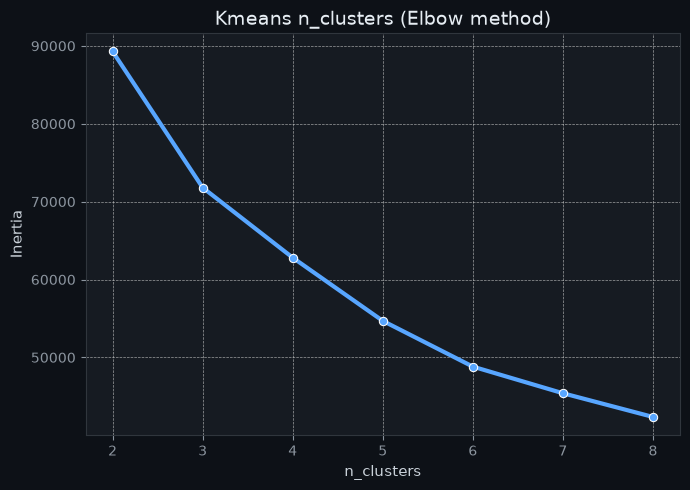

In [4]:
"""I will compare 3 models (KMeans, DBSCAN, HDBSCAN)

First one is KMeans
Second one is DBSCAN
Final is HDBSCAN

All models will be rated by silhouette, davies and calinski metrics
"""
inertia_list = []
n_clusters = range(2, 9)

for n in n_clusters:
    model = KMeans(
        n_clusters=n,
        random_state=42,
        n_init=10
    )
    model.fit(df)
    inertia_list.append(model.inertia_)

plt.figure(figsize=(7, 5))
sns.lineplot(
    x=list(n_clusters),
    y=inertia_list,
    marker="o",
    linewidth=3,
)

plt.title("Kmeans n_clusters (Elbow method)")
plt.xlabel("n_clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# The best n_clusters is 5
BEST_N_CLUSTERS = 5


                    Clustering Results
model_name  silhouette_score  davies_score  calinski_score
    KMeans             0.271         1.334        3000.519



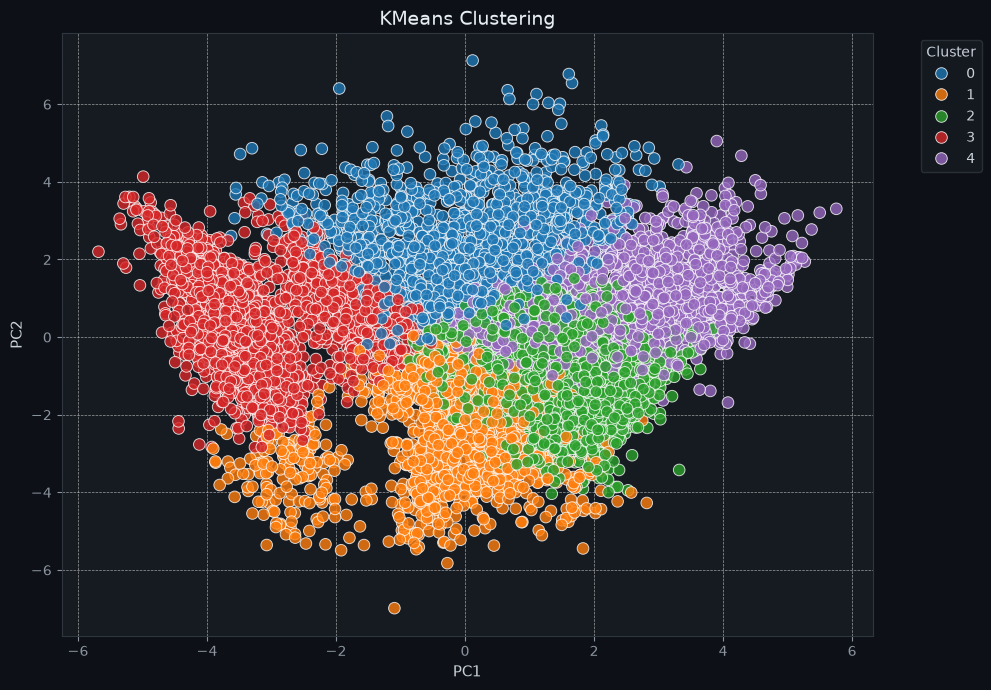

In [5]:
"""
List where will be all 3 model results
There will be model_name, silhouette_score, calinski_harabasz_score, davies_bouldin_score
"""
MODEL_RESULTS = []

kmeans_model = KMeans(
    n_clusters=BEST_N_CLUSTERS,
    random_state=42,
    n_init="auto"
)

MODEL_RESULTS = save_model_result(
    results=MODEL_RESULTS,
    model_name="KMeans",
    x=df,
    model=kmeans_model
)
print_model_result(MODEL_RESULTS)

draw_model_clusters(
    model=kmeans_model,
    title="KMeans Clustering",
    x=df
)